In [1]:
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
import pickle
import numpy.random as rand
import h5py
import time
from tqdm import tqdm
from pathlib import Path

In [2]:
base = Path.cwd().parents[3]
model_dir = [base / "DATA" / "CA_77" / "models" / "model_1.keras", 
             base / "DATA" / "CA_77" / "models" / "model_2.keras", 
             base / "DATA" / "CA_77" / "models" / "model_3.keras", 
             base / "DATA" / "CA_77" / "models" / "model_4.keras", 
             base / "DATA" / "CA_77" / "models" / "model_5.keras"]

loaded_models = [keras.models.load_model(d) for d in model_dir]  # 모델 5개를 한 번만 로드
local_index = pd.read_csv(base / "DATA" / "SDM_data" / "latin" / "local_index.csv")
local_name = local_index["SIG_ENG_NM"].tolist()

with open(base / "DATA" / "SDM_data" / "latin" / "TES_maxent" / "all.pkl", 'rb') as file:
    local_all = pickle.load(file)
with open(base / "DATA" / "SDM_data" / "latin" / "TES_maxent" / "sampling.pkl", 'rb') as file:
    local_lhs = pickle.load(file)
species_path = str(base / "DATA" / "SDM_data" / "latin" / "TES_maxent") #분석하고 싶은 종 선택 (TES)
scenario = ['126', '126', '126', '126'] #시나리오 선택
seeed_num = 10

In [3]:
#lhs
def make_maxent_mat(scenario, loc):
    maxent_mat = []
    for i in ["ssp"+str(scenario[0])+"_2030", "ssp"+str(scenario[1])+"_2050",
              "ssp"+str(scenario[2])+"_2070", "ssp"+str(scenario[3])+"_2090"]:
        dataF = local_lhs[i][loc]
        dataF = dataF.iloc[:,2]
        dataF = np.reshape(dataF,(20,20))
        maxent_mat.append(dataF)
        
    maxent_mat = np.array(maxent_mat)
    maxent_mat = np.transpose(maxent_mat,(1,2,0))
    maxent_mat = np.reshape(maxent_mat,(1,20,20,4))
    return maxent_mat

In [4]:
labels = [8, 6, 2, 34, 38, 12, 10, 14, 26, 30, 58, 62, 74, 78, 106, 110, 40, 44, 42, 46, 136, 140, 138, 142, 154, 158, 168, 172, 170, 174, 186, 190, 130, 134, 162, 166, 234, 238, 202, 206, 24, 28, 56, 60, 152, 156, 184, 188, 4, 18, 22, 36, 50, 54, 72, 76, 90, 94, 104, 108, 122, 126, 132, 146, 150, 160, 164, 178, 182, 200, 204, 218, 222, 232, 236, 250, 254]

In [5]:
weight = np.load(base / "DATA" / "weights" / "WeightByInitial.npy", allow_pickle=True)

In [6]:
def clu_SI(initial, CA_distribution):
    global weight, labels
    SI = 0
    for k, i in enumerate(labels):  # k는 인덱스, i는 labels의 값
        si = CA_distribution[0][k] * weight[i][initial]  # 각 원소를 선택하여 저장
        SI += si
        
    # # 전체 면적으로 나눌 때    
    SI = SI/400
    # # 초기갑으로 나눌 때
    # if initial != 0:
    #     SI = SI / initial
    # else:
    #     SI = 0
    
    return SI

In [7]:
loc = "Anseong-si"
scenario = ['126','126','126','126']
n_rep = 100
maxent_mat = make_maxent_mat(scenario, loc)

In [8]:
# 기존 방식: 격자칸마다 난수를 따로 뽑아 바이너리화
def make_CA_distribution_cellwise(maxent_mat, model):
    b = np.zeros((1, int(model)), dtype=np.float32); initial = 0
    for model_call in loaded_models:
        binary_batch = (np.random.rand(100, 20, 20, 4) < maxent_mat).astype(np.float32)
        initial += np.sum(binary_batch[:,:,:,0])
        b += np.sum(np.array(model_call(binary_batch), dtype=np.float32), axis=0, keepdims=True)
    return int(initial/500), b/500

# 새 방식(global): 위치(i,j)별 난수 R_ij 400개를 뽑아 4개 시기(2030~2090)의 같은 위치 칸이 공유.
# 반복 번호 rep 마다 시드를 고정해 500세트를 한 번에 뽑고(서로 모두 다름), 100개씩 5조각으로 모델 5개에 나눠 넣는다.
# 같은 rep 는 모든 지역/시나리오에서 같은 R_ij 를 쓴다 (저장 없이 재현).
def make_CA_distribution_global(maxent_mat, model, rep):
    R_all = np.random.default_rng(rep).random((500, 20, 20, 1))
    b = np.zeros((1, int(model)), dtype=np.float32); initial = 0
    for m, model_call in enumerate(loaded_models):
        R = R_all[m*100:(m+1)*100]
        binary_batch = (R < maxent_mat).astype(np.float32)
        initial += np.sum(binary_batch[:,:,:,0])
        b += np.sum(np.array(model_call(binary_batch), dtype=np.float32), axis=0, keepdims=True)
    return int(initial/500), b/500

In [9]:
res = {"cellwise": [], "global_shared_Rij": []}
for rep in tqdm(range(n_rep)):
    res["cellwise"].append(clu_SI(*make_CA_distribution_cellwise(maxent_mat, 77)))
    res["global_shared_Rij"].append(clu_SI(*make_CA_distribution_global(maxent_mat, 77, rep)))
df = pd.DataFrame(res)
out = base / "DATA" / "Results" / "77_lhs_Anseong_global_random_126.csv"
out.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out, index=False)
df.describe().T[["mean","std","min","max"]]

  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:00<00:12,  7.67it/s]

  2%|▏         | 2/100 [00:00<00:11,  8.43it/s]

  3%|▎         | 3/100 [00:00<00:11,  8.28it/s]

  4%|▍         | 4/100 [00:00<00:11,  8.18it/s]

...

 98%|█████████▊| 98/100 [00:11<00:00,  9.03it/s]

 99%|█████████▉| 99/100 [00:11<00:00,  9.03it/s]

100%|██████████| 100/100 [00:11<00:00,  9.01it/s]

100%|██████████| 100/100 [00:11<00:00,  8.71it/s]

,mean,std,min,max
cellwise,0.684681,0.002780,0.677697,0.691992
global_shared_Rij,0.738171,0.002641,0.731074,0.747695


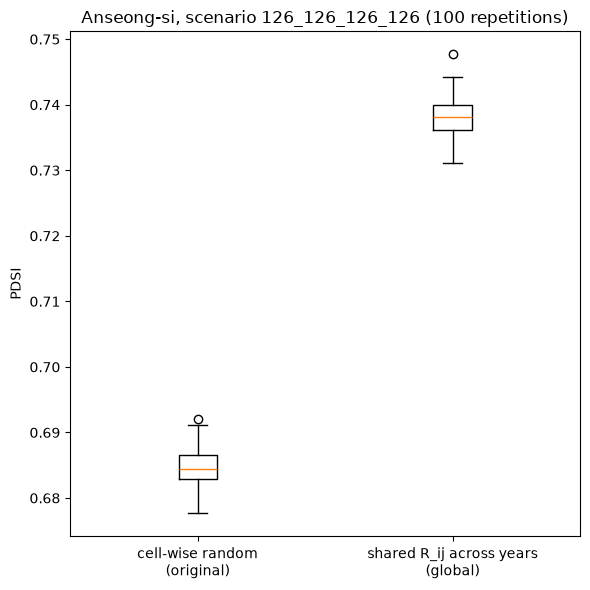

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot([df["cellwise"], df["global_shared_Rij"]], tick_labels=["cell-wise random\n(original)", "shared R_ij across years\n(global)"])
ax.set_ylabel("PDSI"); ax.set_title(f"{loc}, scenario 126_126_126_126 ({n_rep} repetitions)")
plt.tight_layout(); plt.show()